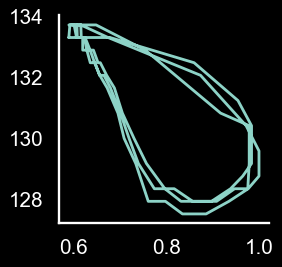

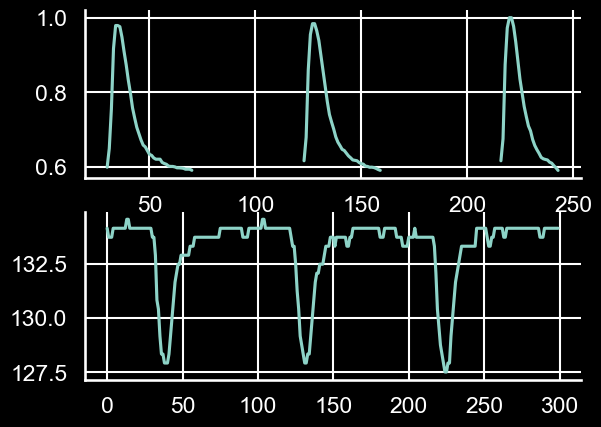

In [43]:
from scipy.signal import medfilt

import pandas as pd
import numpy as np

import seaborn as sns
sns.set_theme('talk')

import matplotlib.pyplot as plt
plt.style.use("dark_background");


path = '/Users/cudmore/Dropbox/data/cell-shortening/paula/kymAnalysis/cell01_C002T001-kymDiameter.csv'

df = pd.read_csv(path, header=1)

# print(df)

sumintensity_raw = df['sumintensity_raw']
diameter_um = df['diameter_um']

sumintensity_raw = medfilt(sumintensity_raw, 3)
diameter_um = medfilt(diameter_um, 3)

startBin = 450 # 110
stopBin = 750  #880

sumintensity_raw = sumintensity_raw[startBin:stopBin]
diameter_um = diameter_um[startBin:stopBin]

# norm to 0..1
sumintensity_raw = sumintensity_raw / np.max(sumintensity_raw)
sumintensity_raw[sumintensity_raw<0.59] = np.nan

fig = plt.figure(figsize=(3, 3), dpi=90)
axs = fig.add_subplot(111)
axs.grid(False)
axs.plot(sumintensity_raw, diameter_um);
sns.despine()
# axs.set_xticklabels([])

fig2, axs2 = plt.subplots(2)
axs2[0].plot(sumintensity_raw)
axs2[1].plot(diameter_um)

sns.despine()
